In [2]:
!pip install timm
import torch
import torch.nn as nn
import torch.optim as optim
import timm
import numpy as np
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.utils.class_weight import compute_class_weight

In [3]:
DATASET_PATH = "/kaggle/input/datasets/sekhsujonhaque/cape-gooseberry-classification-dataset/classification_dataset"

In [4]:
train_transforms = transforms.Compose([
    transforms.Resize((300,300)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(0.2,0.2,0.2,0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((300,300)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [5]:
train_dataset = datasets.ImageFolder(DATASET_PATH + "/train", transform=train_transforms)
val_dataset   = datasets.ImageFolder(DATASET_PATH + "/valid", transform=val_transforms)
test_dataset  = datasets.ImageFolder(DATASET_PATH + "/test", transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32)
test_loader  = DataLoader(test_dataset, batch_size=32)

print("Classes:", train_dataset.classes)

Classes: ['INTERMEDIA', 'MADURO', 'NO_APTA', 'VERDE']


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

Using: cuda


In [7]:
labels = [label for _, label in train_dataset]

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

In [8]:
model = timm.create_model('efficientnet_b3', pretrained=True)

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Unfreeze last few layers
for param in model.blocks[-5:].parameters():
    param.requires_grad = True

# Custom classifier
model.classifier = nn.Sequential(
    nn.BatchNorm1d(model.classifier.in_features),
    nn.Dropout(0.5),
    nn.Linear(model.classifier.in_features, 4)
)

model = model.to(device)

In [9]:
optimizer = optim.AdamW(model.parameters(), lr=0.00015)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

In [10]:
def evaluate(loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total

In [ ]:
EPOCHS = 35
best_val = 0
patience = 5
counter = 0
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    scheduler.step()
    val_acc = evaluate(val_loader)
    if val_acc > best_val:
        best_val = val_acc
        counter = 0
        torch.save(model.state_dict(), "/kaggle/working/best_model.pth")
        print("Best model saved")
    else:
        counter += 1
    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {total_loss:.4f}, Val Acc: {val_acc:.2f}%")
    if counter >= patience:
        print("Early stopping triggered")
        break

In [11]:
model.load_state_dict(torch.load("/kaggle/working/best_model.pth"))
model.eval()
test_acc = evaluate(test_loader)
print("FINAL TEST ACCURACY:", test_acc)

FINAL TEST ACCURACY: 75.0


              precision    recall  f1-score   support

  INTERMEDIA       0.52      0.33      0.40        46
      MADURO       0.75      0.86      0.80        35
     NO_APTA       0.86      0.70      0.78        27
       VERDE       0.76      0.91      0.83        88

    accuracy                           0.73       196
   macro avg       0.72      0.70      0.70       196
weighted avg       0.72      0.73      0.72       196



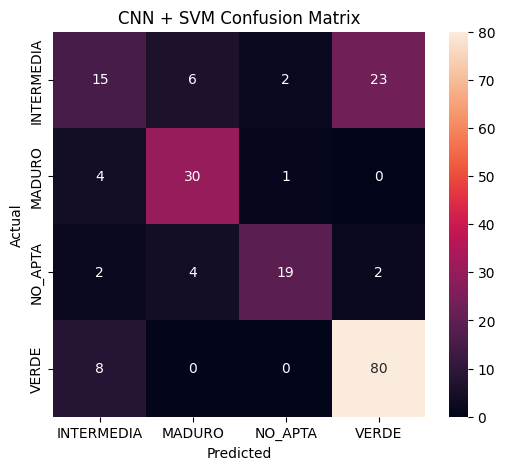

In [12]:
import torch
import torch.nn as nn
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
model.load_state_dict(torch.load("/kaggle/working/best_model.pth"))
model.eval()
feature_extractor = model
feature_extractor.classifier = nn.Identity()
feature_extractor = feature_extractor.to(device)
def extract_features(loader):
    features = []
    labels_list = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = feature_extractor(images)
            outputs = outputs.view(outputs.size(0), -1)
            features.append(outputs.cpu().numpy())
            labels_list.append(labels.numpy())
    return np.vstack(features), np.hstack(labels_list)
X_train, y_train = extract_features(train_loader)
X_test, y_test = extract_features(test_loader)
svm_model = SVC(kernel='rbf', C=10, gamma='scale')
svm_model.fit(X_train, y_train)
y_pred = svm_model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=train_dataset.classes))
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=train_dataset.classes,
            yticklabels=train_dataset.classes)
plt.title("CNN + SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig('CNN_RGB_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()